In [1]:
import os
import numpy as np
import pandas as pd
import rasterio as rio
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from rasterio.plot import plotting_extent 

In [2]:
os.chdir('..')
os.getcwd()

'/Users/rujalshrestha/Projects/mac-migration/gisc-412/nepal-wildfire'

In [3]:
# defining helper function to normalize
def normalize(array):
  arr = array.astype(float)
  arr[arr <= 0] = np.nan
  return (arr - np.nanmin(arr)) / (np.nanmax(arr) - np.nanmin(arr))

# datasets

In [4]:
rasters = {
    "ndvi": "data/Climate/Bardiya_NDVI.tif",
    "lst": "data/Climate/Bardiya_LST.tif",
    "temp": "data/Climate/Bardiya_Temp.tif",
    "precip": "data/Climate/Bardiya_Precip.tif",
    "dem": "output/Topography/cop30_bardiya.tif"
}

bardiya_fire_full = gpd.read_file("output/bardiya_fire.gpkg")
bardiya_fire_full['datetime'] = pd.to_datetime(bardiya_fire_full['datetime'])

bardiya_fire = bardiya_fire_full[
    (bardiya_fire_full['datetime'].dt.year >= 2015) & 
    (bardiya_fire_full['datetime'].dt.year <= 2025)
]

with rio.open(rasters["dem"]) as src:
    dem = src.read(1).astype(float)
    transform = src.transform
    crs = src.crs
    meta = src.meta
    dem_shape = dem.shape

# avoid fire points clustering to one corner due to crs mismatch :')
if bardiya_fire.crs != crs:
    bardiya_fire = bardiya_fire.to_crs(crs)

In [5]:
# calculate and normalize topography layers
xres = transform.a
yres = -transform.e
gy, gx = np.gradient(dem, yres, xres)
slope = np.degrees(np.arctan(np.sqrt(gx**2 + gy**2)))

# topography layers
layers = {
    "elev": normalize(dem),
    "slope": normalize(slope)
}

# climate and vegetation layers
for key in ["ndvi", "lst", "temp", "precip"]:
    with rio.open(rasters[key]) as src:
        data = src.read(out_shape=dem_shape, resampling=Resampling.bilinear)[0]
        layers[key] = normalize(data)

# weights

In [6]:
# weights based on literature and the gwr summary
weights = {
    "ndvi": 0.35,
    "lst": 0.20,
    "temp": 0.15,
    "precip": 0.10,
    "slope": 0.10,
    "elev": 0.10
}

# fire risk mapping

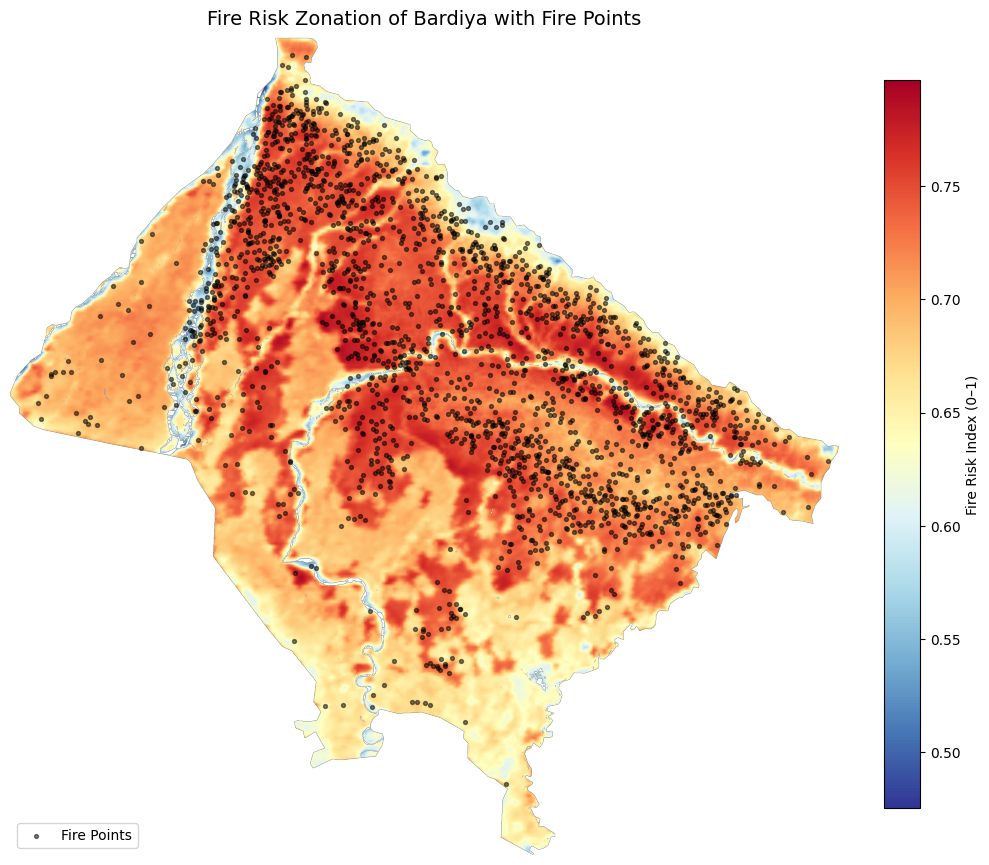

In [7]:
risk_index = sum(weights[k] * layers[k] for k in layers.keys())

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(risk_index, cmap="RdYlBu_r", extent=rio.plot.plotting_extent(src))
plt.colorbar(im, ax=ax, fraction=0.04, label="Fire Risk Index (0–1)")

# overlay recorded wildfires
bardiya_fire.plot(ax=ax, markersize=8, color="black", alpha=0.5, label="Fire Points")

ax.set_title("Fire Risk Zonation of Bardiya with Fire Points", fontsize=14)
ax.axis("off")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()